In [3]:
import tiktoken  # type: ignore
from dotenv.ipython import load_dotenv # type: ignore
import os
from IPython.display import Markdown

In [8]:
load_dotenv(override=True)

True

In [86]:
tokennizer= tiktoken.encoding_for_model("gpt-4o")
print(tokennizer.name)

o200k_base


In [19]:
prompt= "vous etes un assistat expert dans le domaine de l analuse des sentiments"

In [23]:
tokens=tokennizer.encode(prompt)

In [24]:
print(len(tokens))

16


In [25]:
for token in tokens:
   t= tokennizer.decode_single_token_bytes(token).decode("utf-8")
   print (t , end="|")

vous| et|es| un| assist|at| expert| dans| le| domaine| de| l| anal|use| des| sentiments|

In [26]:
def tokens_count(prompt: str, model:str="o200k_base"):
    tokennizer= tiktoken.get_encoding(model)
    return len(tokennizer.encode(prompt))

In [ ]:
print(tokens_count(prompt="vouss etess un assistant"))

5


In [ ]:
from langchain_openai import ChatOpenAI # type: ignore
import os

In [88]:
llm= ChatOpenAI(model="gpt-4o", temperature=0)

In [89]:
resp=llm.invoke(input=[
    { "role":"system","content":"you are a helpful assistant"},
    { "role":"user","content":"c'est quoi un agent ai"}
        ]  )

In [4]:
print(display(Markdown(resp.content)))

NameError: name 'resp' is not defined

In [5]:
from langchain_groq import ChatGroq # type: ignore

ModuleNotFoundError: No module named 'langchain_groq'

In [6]:
llm3=ChatGroq(model="openai/gpt-oss-120b")

NameError: name 'ChatGroq' is not defined

In [7]:
resp=llm3.invoke(input=[
    { "role":"system","content":"you are a helpful assistant"},
    { "role":"user","content":"c'est quoi un agent ai"}
        ]  )

NameError: name 'llm3' is not defined

In [8]:
print(display(Markdown(resp.content)))

NameError: name 'resp' is not defined

In [9]:
from langchain_ollama import ChatOllama # type: ignore

ModuleNotFoundError: No module named 'langchain_ollama'

In [10]:
llm2=ChatOllama(model="llama3.2")

NameError: name 'ChatOllama' is not defined

In [11]:
resp=llm2.invoke(input=[
    { "role":"system","content":"you are a helpful assistant"},
    { "role":"user","content":"c'est quoi un agent ai"}
        ]  )

NameError: name 'llm2' is not defined

In [12]:
print   (display(Markdown(resp.content)))

NameError: name 'resp' is not defined

In [13]:
llm4= ChatOpenAI(model="gpt-5.2")
llm_with_tools= llm4.bind_tools([
    {"type":"image_generation","quality":"high"}
])

NameError: name 'ChatOpenAI' is not defined

In [14]:
from langchain.messages import SystemMessage, HumanMessage, AIMessage

In [15]:
resp=llm_with_tools.invoke(input=[
    SystemMessage(""),
    HumanMessage("je veux une image d un chat qui joue au football")
    
])

NameError: name 'llm_with_tools' is not defined

In [16]:
from IPython.display import Image
import base64

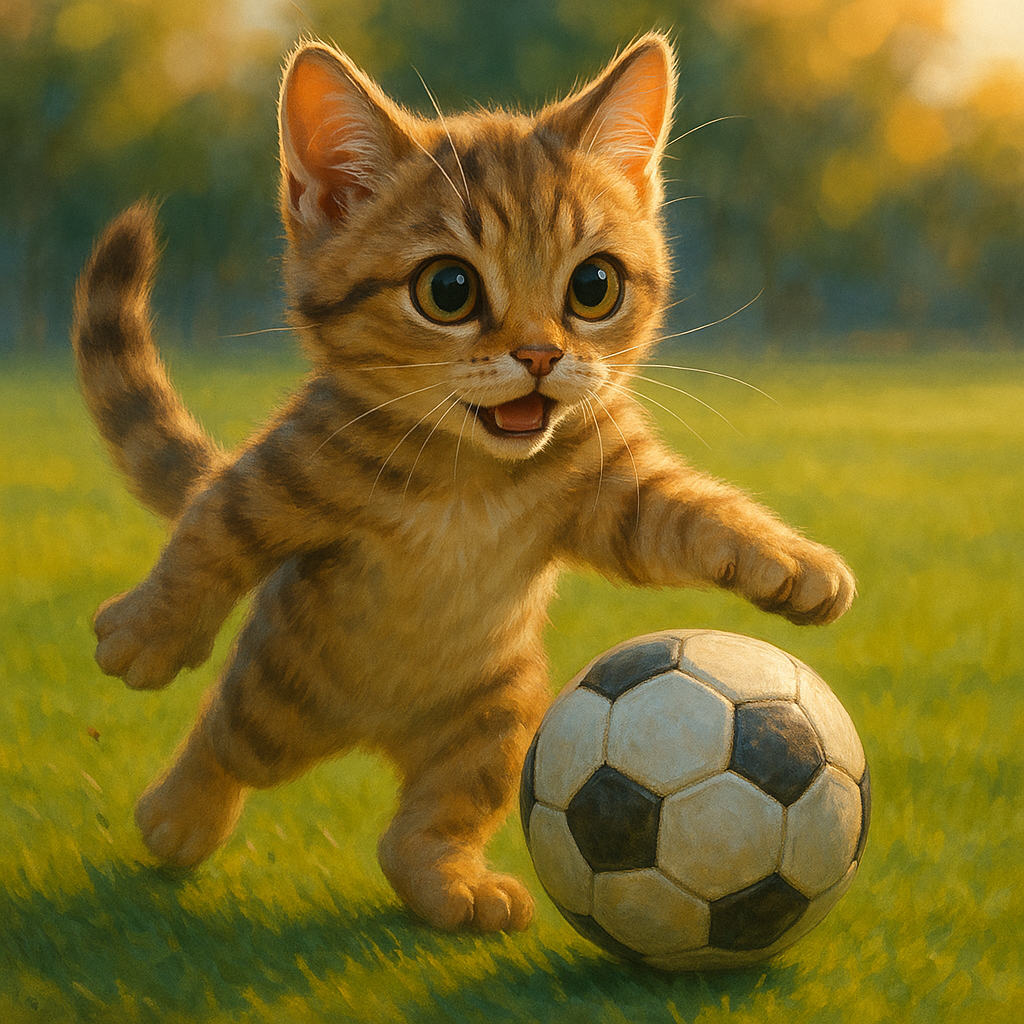

In [41]:
Image(base64.b64decode(resp.content_blocks[0] ['base64']))

In [42]:
path="marmite.png"

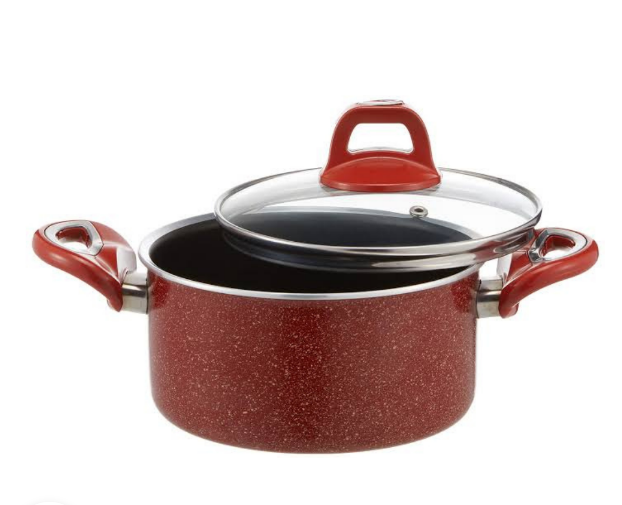

In [43]:
Image(path)

In [44]:
llm5 =ChatOpenAI(model="gpt-5.2")

In [46]:
with open (path, 'rb') as file:
    img= base64.b64encode(file.read()).decode("utf-8")

In [47]:
resp= llm5.invoke (input=[
    HumanMessage(content=[
        {"type":"text","text":"explique moi ce qu'il y a dans l image"},
        {"type":"image_url", "image_url":{"url":f"data:image/png;base64, {img}"}}
    ])
])

In [48]:
print(display(Markdown(resp.content)))

L’image montre une **casserole/une marmite de cuisine** rouge (aspect moucheté), avec **deux poignées latérales** et un **couvercle en verre**. Le couvercle a une **poignée rouge** et un petit **trou/valve** pour laisser s’échapper la vapeur. On l’utilise pour **cuire des aliments** (soupes, pâtes, sauces, etc.).

None


In [62]:
system_message = """
Tu es un assistant spécialisé dans l'analyse de sentiments basée sur les aspects pour les avis concernant les ordinateurs portables.
Ton objectif est d'extraire des informations sur un ou plusieurs des aspects suivants : screen, keyboard et pad.

Pour chaque aspect mentionné dans l'avis de l'utilisateur, tu dois :
1. Confirmer si l'aspect est mentionné (True/False).
2. Déterminer le sentiment (positive, negative ou neutral).
3. Extraire les mots-clés ou phrases qui justifient ce sentiment.
4. Si la polarité n'est pas claire dans l'avis de l'utilisateur, tu supposes que la polarité est neutre.

Réponds strictement sous la forme d'un dictionnaire JSON.
"""

In [63]:
llm6= ChatOpenAI(model="gpt-5.2")

In [64]:
resp=llm6.invoke(input=[
    SystemMessage(system_message),
    HumanMessage("j'ai beaucoup aimer l'ecran de mon nouvel ordinateur portable, mais le clavier est un peu décevant et le pad est correct.")
    
])

In [66]:
print(resp.content)

{
  "screen": {
    "mentioned": true,
    "sentiment": "positive",
    "keywords": ["beaucoup aimer l'ecran"]
  },
  "keyboard": {
    "mentioned": true,
    "sentiment": "negative",
    "keywords": ["le clavier est un peu décevant"]
  },
  "pad": {
    "mentioned": true,
    "sentiment": "neutral",
    "keywords": ["le pad est correct"]
  }
}


In [67]:
import json

In [68]:
sentiment=json.loads(resp.content.replace("```json","").replace("```",""))

In [69]:
print(sentiment)

{'screen': {'mentioned': True, 'sentiment': 'positive', 'keywords': ["beaucoup aimer l'ecran"]}, 'keyboard': {'mentioned': True, 'sentiment': 'negative', 'keywords': ['le clavier est un peu décevant']}, 'pad': {'mentioned': True, 'sentiment': 'neutral', 'keywords': ['le pad est correct']}}


In [71]:

print(sentiment['screen']['sentiment'])

positive


In [ ]:
import session_info # type: ignore
import pandas as pd
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import numpy as np
from datasets import load_dataset # type: ignore
from dotenv.ipython import load_dotenv
import session_info # type: ignore
import matplotlib.pyplot  as plt

In [2]:
load_dotenv(override=True)

True

In [3]:
session_info.show()

In [8]:
ds = load_dataset("imdb")

In [9]:
ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [10]:
train_df=ds['train'].to_pandas()

In [11]:
train_df.sample(10)

,text,label
1323,"the more i think about it, there was nothing r...",0
20737,This movie is excellent. I found it very inter...,1
7739,This movie was pretty bad. Sci-fi is usually m...,0
234,"Well, you know the rest! This has to be the wo...",0
5577,"I wont take too much time here, just wanted to...",0
9675,The film was written 10 years back and a diffe...,0
18556,I saw the movie recently during the Boston Fil...,1
4196,Although the beginning suggests All Quiet on t...,0
17348,I have no idea why this flick is getting such ...,1
11174,This documentary is a reenactment of the last ...,0


In [12]:
train_df['label'].value_counts()

label
0    12500
1    12500
Name: count, dtype: int64

In [13]:
train_df['sentiment']=np.where(train_df['label']==1,'negative','positive')

In [14]:
train_df

,text,label,sentiment
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,positive
1,"""I Am Curious: Yellow"" is a risible and preten...",0,positive
2,If only to avoid making this type of film in t...,0,positive
3,This film was probably inspired by Godard's Ma...,0,positive
4,"Oh, brother...after hearing about this ridicul...",0,positive
...,...,...,...
24995,A hit at the time but now better categorised a...,1,negative
24996,I love this movie like no other. Another time ...,1,negative
24997,This film and it's sequel Barry Mckenzie holds...,1,negative
24998,'The Adventures Of Barry McKenzie' started lif...,1,negative


In [15]:
train_df.sentiment.value_counts()

sentiment
positive    12500
negative    12500
Name: count, dtype: int64

<Axes: >

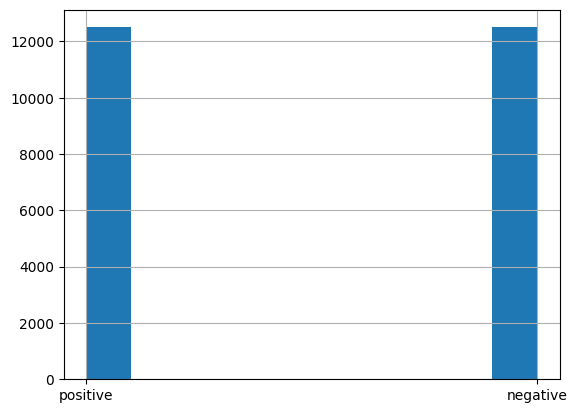

In [20]:
train_df.sentiment.hist()

In [21]:
examples_df, gold_examples_df = train_test_split(
    train_df, test_size=0.2, random_state=123 
)

In [22]:
(examples_df.shape, gold_examples_df.shape)

((20000, 3), (5000, 3))

In [34]:
print(type(gold_examples_df))

<class 'str'>


In [36]:
columns = ['text', 'label']

gold_examples = (
    train_df[columns]
    .sample(20, random_state=42)
    .to_json(orient='records')
)

In [38]:
import json

In [39]:
json.loads(gold_examples)

[{'text': 'Dumb is as dumb does, in this thoroughly uninteresting, supposed black comedy. Essentially what starts out as Chris Klein trying to maintain a low profile, eventually morphs into an uninspired version of "The Three Amigos", only without any laughs. In order for black comedy to work, it must be outrageous, which "Play Dead" is not. In order for black comedy to work, it cannot be mean spirited, which "Play Dead" is. What "Play Dead" really is, is a town full of nut jobs. Fred Dunst does however do a pretty fair imitation of Billy Bob Thornton\'s character from "A Simple Plan", while Jake Busey does a pretty fair imitation of, well, Jake Busey. - MERK',
  'label': 0},
 {'text': "I dug out from my garage some old musicals and this is another one of my favorites. It was written by Jay Alan Lerner and directed by Vincent Minelli. It won two Academy Awards for Best Picture of 1951 and Best Screenplay. The story of an American painter in Paris who tries to make it big. Nina Foch is 

In [40]:
user_message_template = """```{movie_review}```"""

In [41]:
zero_shot_system_message = """
Classify the sentiment of movie reviews presented in the input as 'positive' or 'negative'
Movie reviews will be delimited by triple backticks in the input.
Answer only 'positive' or 'negative' 
Do not explain your answer.
"""

In [42]:
zero_shot_prompt = [{'role':'system', 'content': zero_shot_system_message}]

In [43]:
few_shot_system_message = """
Classify the sentiment of movie reviews presented in the input as 'positive' or 'negative'
Movie reviews will be delimited by triple backticks in the input.
Answer only 'positive' or 'negative'
Do not explain your answer.
"""

In [47]:
examples_df

,text,label,sentiment
9064,Ulises is a literature teacher that arrives to...,0,positive
6051,Tarzan the Ape Man is a remake of the 1932 fil...,0,positive
17848,This movie is great! This movie is beautiful! ...,1,negative
5408,"Typical Troma-trash, this smutty 80's flick is...",0,positive
18025,Roman Polanski masterfully directs this sort o...,1,negative
...,...,...,...
15377,Cinderella was one of the first movies I ever ...,1,negative
21602,Dev Anand (or Prashant) and Zeenat Aman ( Jasb...,1,negative
17730,"Interesting, fast-paced and amusing.<br /><br ...",1,negative
15725,Perhaps the most polished and accomplished of ...,1,negative


In [48]:
positive_examples = examples_df [examples_df['sentiment'] == 'positive']

In [49]:
negative_examples = examples_df [examples_df['sentiment'] == 'negative']

In [50]:
negative_examples.shape,positive_examples.shape

((9963, 3), (10037, 3))

In [51]:
negative_reviews.shape,positive_reviews.shape

((20000,), (20000,))

In [44]:
positive_reviews = (examples_df.sentiment == 'positive')
negative_reviews = (examples_df.sentiment == 'negative')

In [45]:
(positive_reviews.shape, negative_reviews.shape)

((20000,), (20000,))

In [73]:
negative_examples = negative_reviews.sample(4).to_json(orient='records')
print(negative_examples)

[true,false,false,false]


In [ ]:
positive_examples = positive_reviews.sample(4).to_json(orient='records')
print(positive_examples)

[true,false,false,true]


In [66]:
columns = ['text', 'sentiment']
positive_examples = examples_df.loc[positive_reviews, columns].sample(4)
negative_examples = examples_df.loc[negative_reviews, columns].sample(4)

In [67]:
positive_examples

,text,sentiment
2810,<br /><br />Although the lead actress is STRIK...,positive
961,How did this become a blockbuster? Dear God I ...,positive
1634,The movie uses a cutting edge title for a lame...,positive
6478,Imagine The Big Chill with a cast of twenty-so...,positive


In [68]:
negative_examples

,text,sentiment
14401,I can understand why some people like this mov...,negative
19361,Let's go straight to the point: this is The Mo...,negative
19824,Almost the entire film takes place in a public...,negative
13556,"Sandra Bernhard's Without You I'm Nothing, the...",negative


In [ ]:
def create_examples(dataset, n=4):
    positive_reviews = (dataset.sentiment == 'positive')
    negative_reviews = (dataset.sentiment == 'negative')
    columns_to_select = ['text', 'sentiment']
    positive_examples = dataset.loc[positive_reviews, columns_to_select].sample(n)
    negative_examples = dataset.loc[negative_reviews, columns_to_select].sample(n)
    examples = pd.concat([positive_examples, negative_examples])
    randomized_examples = examples.sample(2*n, replace=False)
    return randomized_examples.to_json(orient='records')

In [75]:
examples = create_examples(examples_df, 2)

In [76]:
json.loads(examples)

[{'text': 'An American in Paris is a wonderful musical about an American painter living in Paris for inspiration. He meets a rich woman who admires his paintings on the street and she believes she can get his work to be even more popular to the public, e.g. in a museum. Golden Globe nominated Gene Kelly as the artist Jerry Mulligan is just perfect at both singing and especially dancing. He also meets the main girl Lise Bouvier (Leslie Caron) who is engaged to his best friend. He can\'t help his feelings for this girl, even after he finds out who she is engaged to. Filled with nice romance and wonderful song and dance, this is a very good musical film. It may drag slightly with his dancing dream sequence, i.e. The American in Paris ballet, but there is a good happy ending. It won the Oscars for Best Art Direction-Set Decoration, Best Cinematography, Best Costume Design, Best Music, Scoring of a Musical Picture, Best Writing, Story and Screenplay and Best Picture, and it was nominated fo

In [77]:
def create_prompt(system_message, examples, user_message_template):
    few_shot_prompt = [{'role':'system', 'content': system_message}]
    for example in json.loads(examples):
        example_review = example['text']
        example_sentiment = example['sentiment']
        few_shot_prompt.append(
            {
                'role': 'user',
                'content': user_message_template.format(
                    movie_review=example_review
                )
            }
        )
        few_shot_prompt.append(
            {'role': 'assistant', 'content': f"{example_sentiment}"}
        )
    return few_shot_prompt

In [78]:
few_shot_prompt = create_prompt(
    few_shot_system_message,
    examples,
    user_message_template
)

In [79]:
few_shot_prompt

[{'role': 'system',
  'content': "\nClassify the sentiment of movie reviews presented in the input as 'positive' or 'negative'\nMovie reviews will be delimited by triple backticks in the input.\nAnswer only 'positive' or 'negative'\nDo not explain your answer.\n"},
 {'role': 'user',
  'content': '```An American in Paris is a wonderful musical about an American painter living in Paris for inspiration. He meets a rich woman who admires his paintings on the street and she believes she can get his work to be even more popular to the public, e.g. in a museum. Golden Globe nominated Gene Kelly as the artist Jerry Mulligan is just perfect at both singing and especially dancing. He also meets the main girl Lise Bouvier (Leslie Caron) who is engaged to his best friend. He can\'t help his feelings for this girl, even after he finds out who she is engaged to. Filled with nice romance and wonderful song and dance, this is a very good musical film. It may drag slightly with his dancing dream sequen

In [80]:
cot_system_message = """
Classify the sentiment of movie reviews presented in the input as 'positive' or 'negative'
Movie reviews will be delimited by triple backticks ``` in the input.
Answer only 'positive' or 'negative' 
Do not explain your answer.

Instructions:
1. Carefully read the text of the review and think through the options for sentiment provided
2. Consider the overall sentiment of the review and estimate the probability of the review being positive

To reiterate, your answer should strictly only contain the label: positive or negative
"""

In [81]:
cot_few_shot_prompt = create_prompt(cot_system_message, examples, user_message_template)

In [82]:
cot_few_shot_prompt

[{'role': 'system',
  'content': "\nClassify the sentiment of movie reviews presented in the input as 'positive' or 'negative'\nMovie reviews will be delimited by triple backticks ``` in the input.\nAnswer only 'positive' or 'negative' \nDo not explain your answer.\n\nInstructions:\n1. Carefully read the text of the review and think through the options for sentiment provided\n2. Consider the overall sentiment of the review and estimate the probability of the review being positive\n\nTo reiterate, your answer should strictly only contain the label: positive or negative\n"},
 {'role': 'user',
  'content': '```An American in Paris is a wonderful musical about an American painter living in Paris for inspiration. He meets a rich woman who admires his paintings on the street and she believes she can get his work to be even more popular to the public, e.g. in a museum. Golden Globe nominated Gene Kelly as the artist Jerry Mulligan is just perfect at both singing and especially dancing. He als

In [83]:
def evaluate_prompt(prompt, gold_examples, user_message_template, model):
    model_predictions, ground_truths = [], []

    for example in json.loads(gold_examples):
        gold_input = example['text']
        user_input = [
            {
                'role':'user',
                'content': user_message_template.format(movie_review=gold_input)
            }
        ]

        try:
            response = model.invoke(
               prompt+user_input
            )
            if hasattr (response, 'content'):
                response_content = response.content
            else:
                response_content = response    
            if 'negative' in response_content.strip().lower():
                prediction='negative'
            elif 'positive' in response_content.strip().lower():
                prediction='positive'
            else:
                prediction ='unknown'
            model_predictions.append(prediction)
            ground_truths.append(example['sentiment'])
            #print(prediction, example['sentiment'])

        except Exception as e:
            print(e)
            continue

    micro_f1_score = f1_score(ground_truths, model_predictions, average="micro")

    return micro_f1_score

In [90]:
gpt5 = ChatOpenAI(
    model="gpt-5.2", temperature=0
    )

In [92]:
evaluate_prompt(zero_shot_prompt, gold_examples, user_message_template, gpt5)

'sentiment'
'sentiment'
'sentiment'
'sentiment'
'sentiment'
'sentiment'
'sentiment'
'sentiment'
'sentiment'
'sentiment'
'sentiment'
'sentiment'
'sentiment'
'sentiment'
'sentiment'
'sentiment'
'sentiment'
'sentiment'
'sentiment'
'sentiment'


ValueError: Found input variables with inconsistent numbers of samples: [0, 20]

In [93]:
evaluate_prompt(few_shot_prompt, gold_examples, user_message_template, gpt5)

'sentiment'
'sentiment'
'sentiment'
'sentiment'
'sentiment'
'sentiment'
'sentiment'
'sentiment'
'sentiment'
'sentiment'
'sentiment'
'sentiment'
'sentiment'
'sentiment'
'sentiment'
'sentiment'
'sentiment'
'sentiment'
'sentiment'
'sentiment'


ValueError: Found input variables with inconsistent numbers of samples: [0, 20]